# LunarLander-v3 Exploration

This notebook explores the `LunarLander-v3` environment from `gymnasium` and explains the parts that matter when building or debugging an RL agent.

It is intentionally practical: we inspect the observation and action spaces, probe a few transitions, summarize the reward structure, and collect simple rollout statistics.

## Setup

The project already depends on `gymnasium` and `box2d`. This notebook uses the discrete version of the environment, which is the default for `LunarLander-v3`.

In [ ]:
from __future__ import annotations

from pprint import pprint

import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np
from gymnasium.envs.box2d.lunar_lander import heuristic

In [13]:
plt.rc("font", size=14)
plt.rc("axes", labelsize=14, titlesize=14)
plt.rc("legend", fontsize=14)
plt.rc("xtick", labelsize=10)
plt.rc("ytick", labelsize=10)
plt.rc("animation", html="jshtml")

In [14]:
ENV_ID = "LunarLander-v3"
SEED = 42

env = gym.make(ENV_ID)
obs, info = env.reset(seed=SEED)

print("spec:", env.spec)
print("observation space:", env.observation_space)
print("action space:", env.action_space)
print("initial observation:", obs)
print("reset info:", info)

spec: EnvSpec(id='LunarLander-v3', entry_point='gymnasium.envs.box2d.lunar_lander:LunarLander', reward_threshold=200, nondeterministic=False, max_episode_steps=1000, order_enforce=True, disable_env_checker=False, kwargs={}, namespace=None, name='LunarLander', version=3, additional_wrappers=(), vector_entry_point=None)
observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
action space: Discrete(4)
initial observation: [ 0.00229702  1.4181306   0.23264714  0.32046658 -0.00265488 -0.05269808
  0.          0.        ]
reset info: {}


## What the state means

The observation is an 8-dimensional vector:

1. horizontal position `x`
2. vertical position `y`
3. horizontal velocity `vx`
4. vertical velocity `vy`
5. angle
6. angular velocity
7. left leg contact
8. right leg contact

The first six values are continuous. The last two are binary contact indicators.

The environment returns values that are roughly normalized to a compact range, but they are not standardized features. Position, velocity, and angle still have different semantics and scales.

In [ ]:
state_names = [
    "x position",
    "y position",
    "x velocity",
    "y velocity",
    "angle",
    "angular velocity",
    "left leg contact",
    "right leg contact",
]

for idx, (name, low, high, value) in enumerate(
    zip(state_names, env.observation_space.low, env.observation_space.high, obs, strict=False)
):
    print(
        f"{idx}: {name:>18} | low={low:>8.3f} | high={high:>8.3f} | sample={value:>8.3f}"
    )

0:         x position | low=  -2.500 | high=   2.500 | sample=   0.002
1:         y position | low=  -2.500 | high=   2.500 | sample=   1.418
2:         x velocity | low= -10.000 | high=  10.000 | sample=   0.233
3:         y velocity | low= -10.000 | high=  10.000 | sample=   0.320
4:              angle | low=  -6.283 | high=   6.283 | sample=  -0.003
5:   angular velocity | low= -10.000 | high=  10.000 | sample=  -0.053
6:   left leg contact | low=  -0.000 | high=   1.000 | sample=   0.000
7:  right leg contact | low=  -0.000 | high=   1.000 | sample=   0.000


## Action space

This version uses a discrete action space with 4 actions:

- `0`: do nothing
- `1`: fire left orientation engine
- `2`: fire main engine
- `3`: fire right orientation engine

A useful intuition is that action `2` mainly fights gravity, while actions `1` and `3` mostly control orientation and sideways drift.

In [4]:
action_meanings = {
    0: "do nothing",
    1: "fire left orientation engine",
    2: "fire main engine",
    3: "fire right orientation engine",
}

pprint(action_meanings)

{0: 'do nothing',
 1: 'fire left orientation engine',
 2: 'fire main engine',
 3: 'fire right orientation engine'}


## Immediate effect of each action

To isolate action effects, we reset the environment to the same seed before applying one action. The next state and reward change because the physics engine reacts differently to each thrust command.

In [ ]:
def one_step_from_reset(action: int, seed: int = SEED) -> dict[str, object]:
    probe_env = gym.make(ENV_ID)
    start_obs, _ = probe_env.reset(seed=seed)
    next_obs, reward, terminated, truncated, _ = probe_env.step(action)
    probe_env.close()
    return {
        "action": action,
        "meaning": action_meanings[action],
        "start_obs": start_obs,
        "next_obs": next_obs,
        "delta": next_obs - start_obs,
        "reward": reward,
        "terminated": terminated,
        "truncated": truncated,
    }


for action in range(env.action_space.n):
    result = one_step_from_reset(action)
    print(f"action={result['action']} ({result['meaning']})")
    print("reward:", round(result["reward"], 4))
    print("delta:", np.round(result["delta"], 4))
    print()

action=0 (do nothing)
reward: 1.145
delta: [ 0.0023  0.0066 -0.0003 -0.0257 -0.0026  0.0006  0.      0.    ]

action=1 (fire left orientation engine)
reward: 2.0805
delta: [ 0.0022  0.0066 -0.0123 -0.0256 -0.0002  0.0488  0.      0.    ]

action=2 (fire main engine)
reward: -2.497
delta: [ 0.0021  0.0077 -0.0153  0.0235 -0.0034 -0.0147  0.      0.    ]

action=3 (fire right orientation engine)
reward: 0.4748
delta: [ 0.0024  0.0066  0.0074 -0.0257 -0.0041 -0.0303  0.      0.    ]



## Reward structure

The environment computes a shaping score based on:

- distance from the landing pad
- speed magnitude
- tilt angle
- leg contact bonuses

The step reward is mostly the *change* in shaping from one step to the next, minus fuel costs:

- main engine cost: `0.30` per step
- side engine cost: `0.03` per step

Terminal outcomes are strong:

- crash or leaving the allowed horizontal range: `-100`
- successful landing / sleeping body: `+100`

This means a good agent must do more than survive. It must become progressively closer, slower, and more upright while spending fuel carefully.

In [15]:
print("reward threshold from spec:", env.spec.reward_threshold)
print("time limit from spec:", env.spec.max_episode_steps)

reward threshold from spec: 200
time limit from spec: 1000


## Random policy rollout statistics

A random policy is not useful for solving the task, but it gives a baseline for episode length and return scale. This is helpful when validating that training is actually improving behavior.

In [ ]:
def run_random_episode(seed: int | None = None) -> tuple[float, int, np.ndarray]:
    rollout_env = gym.make(ENV_ID)
    obs, _ = rollout_env.reset(seed=seed)
    done = False
    total_reward = 0.0
    steps = 0
    last_obs = obs

    while not done:
        action = rollout_env.action_space.sample()
        last_obs, reward, terminated, truncated, _ = rollout_env.step(action)
        total_reward += reward
        steps += 1
        done = terminated or truncated

    rollout_env.close()
    return total_reward, steps, last_obs


returns = []
lengths = []

for seed in range(10):
    total_reward, steps, last_obs = run_random_episode(seed)
    returns.append(total_reward)
    lengths.append(steps)

print(f"episodes: {len(returns)}")
print(f"mean return: {np.mean(returns):.2f}")
print(f"std return: {np.std(returns):.2f}")
print(f"min return: {np.min(returns):.2f}")
print(f"max return: {np.max(returns):.2f}")
print(f"mean length: {np.mean(lengths):.2f}")

episodes: 10
mean return: -179.29
std return: 121.95
min return: -350.98
max return: 80.21
mean length: 99.90


## Rendering frames

The example notebook renders environments by requesting `rgb_array` frames and plotting them with Matplotlib. We do the same here.

This gives two useful views:

- a single-frame snapshot for inspecting one state
- an animation for understanding how a policy behaves over time

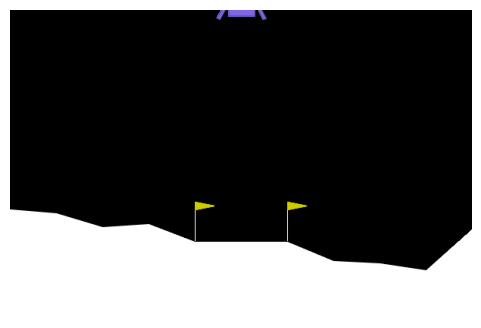

frame type: <class 'numpy.ndarray'>
frame shape: (400, 600, 3)
frame dtype: uint8


In [ ]:
def plot_environment(env: gym.Env, figsize: tuple[int, int]=(6, 4)) -> np.ndarray:
    plt.figure(figsize=figsize)
    img = env.render()
    plt.imshow(img)
    plt.axis("off")
    return img


rgb_env = gym.make(ENV_ID, render_mode="rgb_array")
rgb_env.reset(seed=SEED)
frame = plot_environment(rgb_env)
rgb_env.close()
plt.show()

print("frame type:", type(frame))
print("frame shape:", frame.shape)
print("frame dtype:", frame.dtype)

## Episode animation

A single frame is useful for inspection, but LunarLander is much easier to understand as a short animation.

In [ ]:
def update_scene(num: int, frames: list[np.ndarray], patch: plt.image.AxesImage) -> tuple[plt.image.AxesImage]:
    patch.set_data(frames[num])
    return (patch,)


def plot_animation(frames: list[np.ndarray], repeat: bool = False, interval: int = 50) -> plt.animation.FuncAnimation:
    fig = plt.figure()
    patch = plt.imshow(frames[0])
    plt.axis("off")
    anim = plt.animation.FuncAnimation(  
        fig,
        update_scene,
        fargs=(frames, patch),
        frames=len(frames),
        repeat=repeat,
        interval=interval,
    )
    plt.close()
    return anim


def render_heuristic_episode(n_max_steps: int = 300, seed: int = SEED) -> list[np.ndarray]:
    frames = []
    rollout_env = gym.make(ENV_ID, render_mode="rgb_array")
    obs, _ = rollout_env.reset(seed=seed)
    for _ in range(n_max_steps):
        frames.append(rollout_env.render())
        action = heuristic(rollout_env.unwrapped, obs)
        obs, _, terminated, truncated, _ = rollout_env.step(action)
        if terminated or truncated:
            break
    rollout_env.close()
    return frames


frames = render_heuristic_episode(seed=SEED)
print(f"captured {len(frames)} frames")
plot_animation(frames)

captured 235 frames


In [19]:
env.close()